dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   object 
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB
None

dataset stats:
          meantemp     humidity   wind_speed  meanpressure
count  1576.000000  1576.000000  1576.000000   1576.000000
mean     25.221918    60.445229     6.899262   1010.593178
std       7.345014    16.979994     4.510725    175.242704
min       6.000000    13.428571     0.000000     -3.041667
25%      18.500000    49.750000     3.700000   1001.875000
50%      27.166667    62.440476     6.363571   1009.055556
75%      31.142857    72.125000     9.262500   1015.200000
max      38.714286   100.000000  

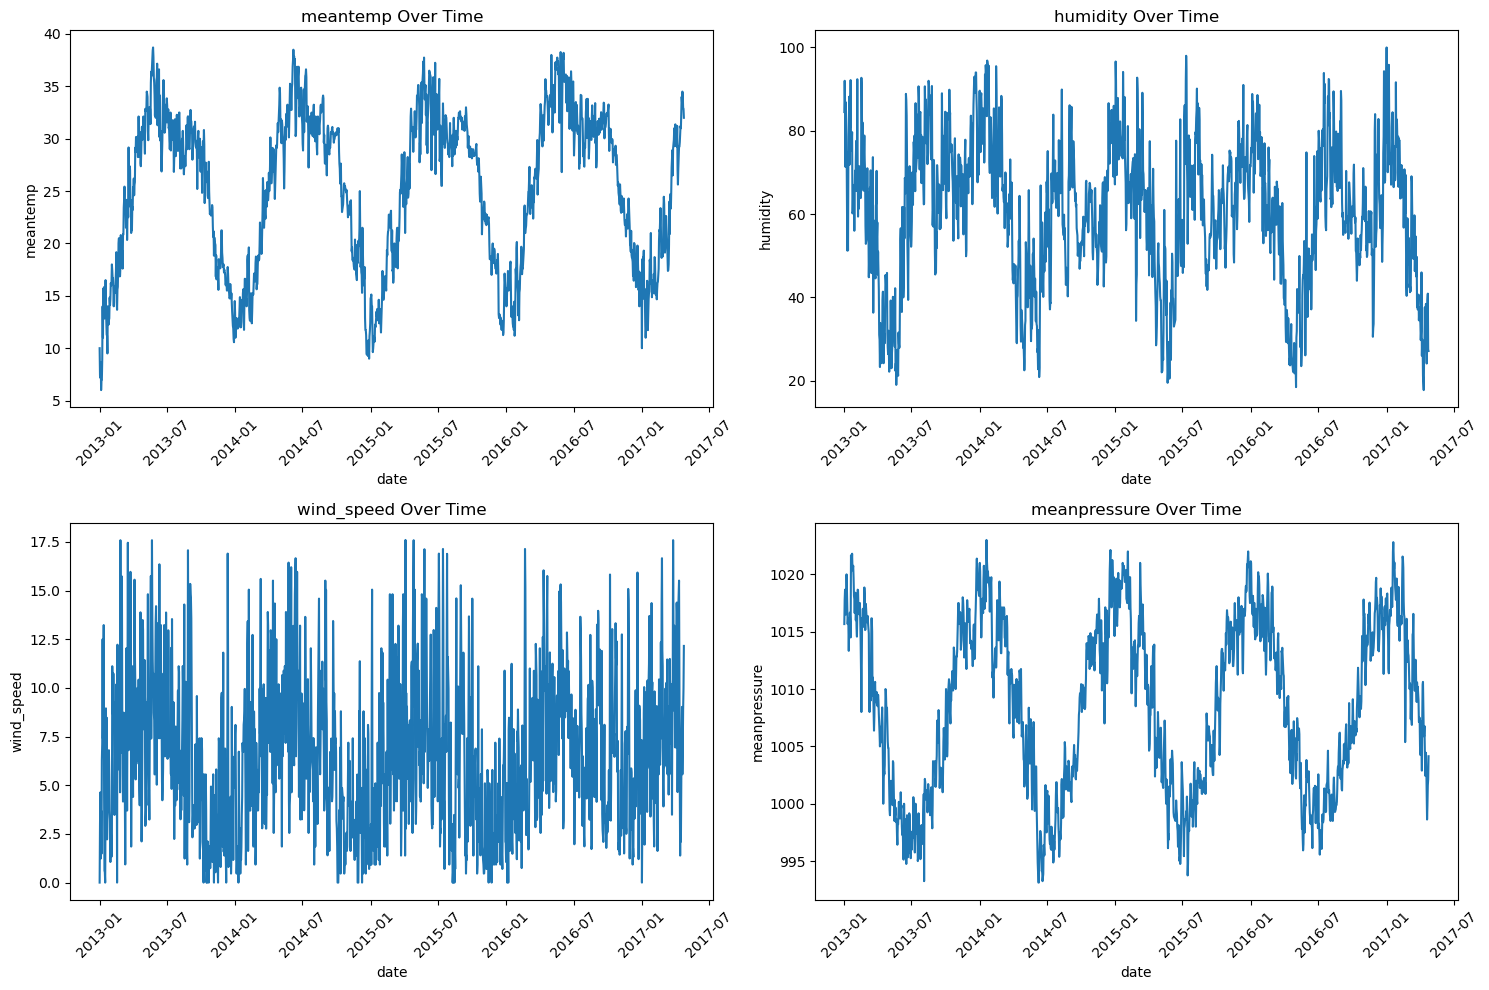

r2_score: 0.9515
mae: 1.1865
mse: 2.4130
rmse: 1.5534


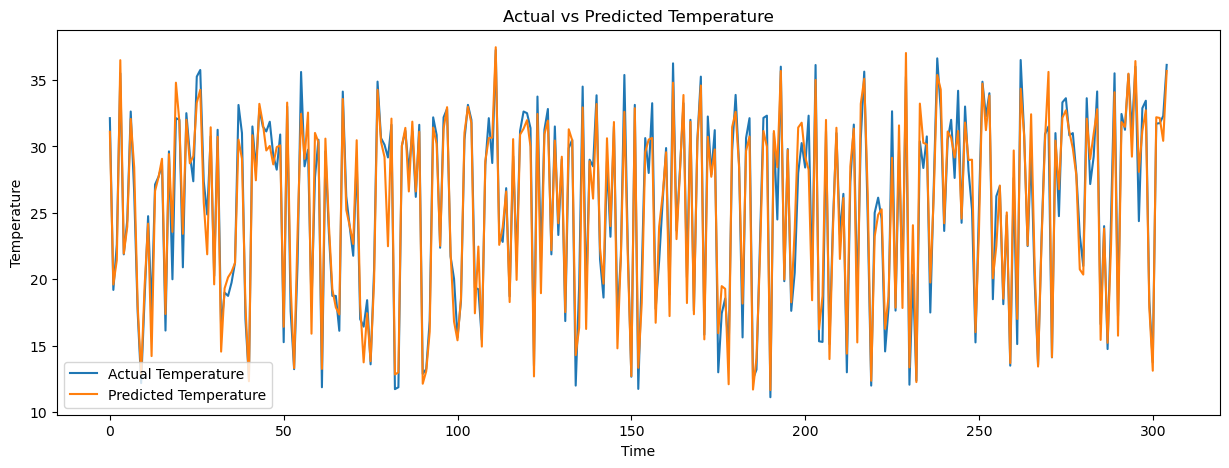

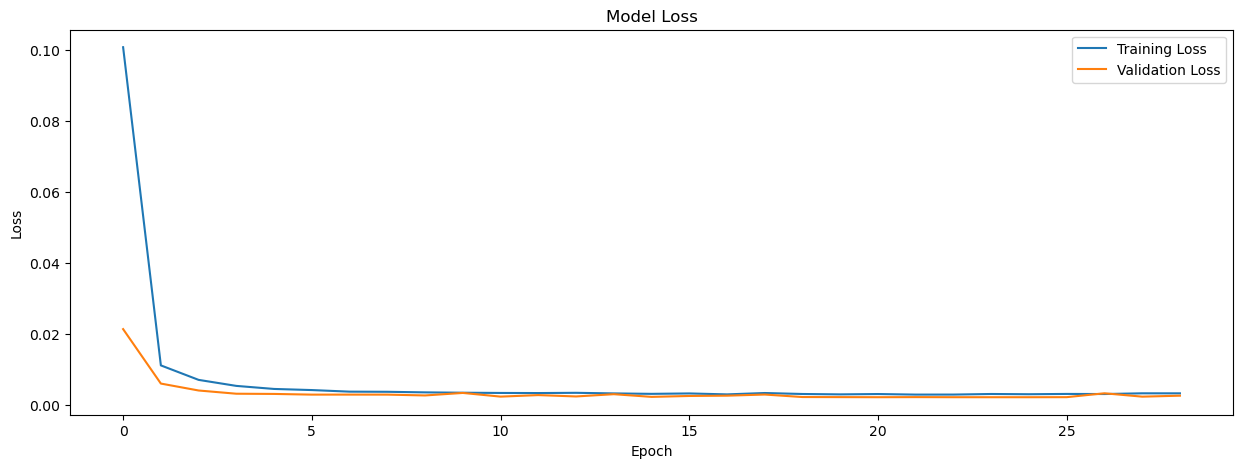

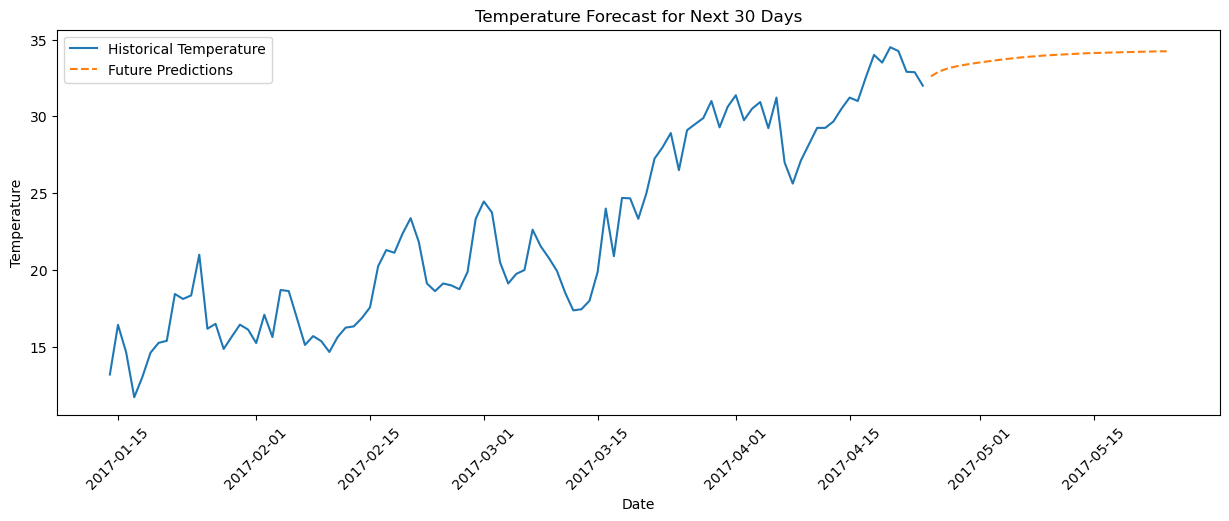


future predictions for the next 30 days:
2017-04-25: 32.61°C
2017-04-26: 32.92°C
2017-04-27: 33.11°C
2017-04-28: 33.24°C
2017-04-29: 33.34°C
2017-04-30: 33.43°C
2017-05-01: 33.51°C
2017-05-02: 33.58°C
2017-05-03: 33.65°C
2017-05-04: 33.72°C
2017-05-05: 33.78°C
2017-05-06: 33.83°C
2017-05-07: 33.88°C
2017-05-08: 33.92°C
2017-05-09: 33.96°C
2017-05-10: 33.99°C
2017-05-11: 34.02°C
2017-05-12: 34.05°C
2017-05-13: 34.08°C
2017-05-14: 34.10°C
2017-05-15: 34.12°C
2017-05-16: 34.14°C
2017-05-17: 34.15°C
2017-05-18: 34.17°C
2017-05-19: 34.18°C
2017-05-20: 34.19°C
2017-05-21: 34.21°C
2017-05-22: 34.22°C
2017-05-23: 34.23°C
2017-05-24: 34.24°C


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

train_df = pd.read_csv(r'C:\Users\X\Desktop\X\2023\ML\DailyDelhiClimateTrain.csv')
test_df = pd.read_csv(r'C:\Users\X\Desktop\X\2023\ML\DailyDelhiClimateTest.csv')
df = pd.concat([train_df, test_df], ignore_index=True)

print("dataset info:")
print(df.info())
print("\ndataset stats:")
print(df.describe())

def remvoutliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in ['meantemp', 'humidity', 'wind_speed', 'meanpressure']:
    df = remvoutliers(df, col)

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

plt.figure(figsize=(15, 10))
for i, column in enumerate(['meantemp', 'humidity', 'wind_speed', 'meanpressure'], 1):
    plt.subplot(2, 2, i)
    sns.lineplot(data=df, x=df.index, y=column)
    plt.title(f'{column} Over Time')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']])
seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, dense_size=64, output_size=1, dropout_rate=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size * 2, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, output_size)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = LSTMModel(input_size=4)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_losses = []
val_losses = []
patience = 5
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(100):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_output = model(X_test.to(device))
        val_loss = criterion(val_output.squeeze(), y_test.to(device)).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'cli.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break

model.load_state_dict(torch.load('cli.pt'))
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()

y_test_reshaped = np.repeat(y_test.numpy().reshape(-1, 1), 4, axis=1)
y_pred_reshaped = np.repeat(y_pred, 4, axis=1)
y_test_inv = scaler.inverse_transform(y_test_reshaped)[:, 0]
y_pred_inv = scaler.inverse_transform(y_pred_reshaped)[:, 0]

def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mse = mean_squared_error(actual, pred)
    r2 = r2_score(actual, pred)
    return {"r2_score": r2, "mae": mae, "mse": mse, "rmse": rmse}

metrics = eval_metrics(y_test_inv, y_pred_inv)

print(f"r2_score: {metrics['r2_score']:.4f}")
print(f"mae: {metrics['mae']:.4f}")
print(f"mse: {metrics['mse']:.4f}")
print(f"rmse: {metrics['rmse']:.4f}")



plt.figure(figsize=(15, 5))
plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(y_pred_inv, label='Predicted Temperature')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_data[-seq_length:]
future_predictions = []

current_sequence = last_sequence.copy()
for _ in range(future_steps):
    current_sequence_tensor = torch.FloatTensor(current_sequence).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(current_sequence_tensor).cpu().numpy()[0, 0]
    future_predictions.append(pred)
    new_row = np.array([pred, current_sequence[-1, 1], current_sequence[-1, 2], current_sequence[-1, 3]])
    current_sequence = np.vstack((current_sequence[1:], new_row))

future_predictions_reshaped = np.repeat(np.array(future_predictions).reshape(-1, 1), 4, axis=1)
future_predictions_inv = scaler.inverse_transform(future_predictions_reshaped)[:, 0]

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

plt.figure(figsize=(15, 5))
plt.plot(df.index[-100:], df['meantemp'][-100:], label='Historical Temperature')
plt.plot(future_dates, future_predictions_inv, label='Future Predictions', linestyle='--')
plt.title('Temperature Forecast for Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("\nfuture predictions for the next 30 days:")
for date, pred in zip(future_dates, future_predictions_inv):
    print(f"{date.strftime('%Y-%m-%d')}: {pred:.2f}°C")